# Tillamook LiDAR Channels & Landslide Ground Truth Visualization

This notebook provides a **single, self-contained Python code** to load, analyze, and display all **7 LiDAR-derived terrain channels** alongside the **SLIDO Landslide Ground Truth Mask** for the Tillamook, Oregon study area.

### The 7 LiDAR Input Channels:
1. **Local Relief (`m`)**: Detrended elevation subtracting regional trend, highlighting local ridge-to-valley elevation changes.
2. **Slope (`degrees`)**: Surface gradient / steepness, the fundamental driving factor in slope failure physics.
3. **Aspect (Sin)**: Sine of slope aspect, encoding East-West directional exposure to weather and insolation.
4. **Aspect (Cos)**: Cosine of slope aspect, encoding North-South directional orientation (moisture regime).
5. **Curvature (`1/m`)**: Topographic concavity vs convexity, identifying converging gullies and diverging ridges.
6. **Multidirectional Hillshade**: Multi-azimuth illuminated relief revealing scarps, hummocky landslide deposits, and bench structures.
7. **Terrain Ruggedness Index - TRI (`m`)**: Mean difference between a central pixel and its 8 neighbors, capturing geomorphic surface roughness.

### Ground Truth Target:
- **SLIDO Landslide Mask**: Statewide Landslide Information Database for Oregon (DOGAMI), with validated historic and prehistoric landslide deposits and scarps.

TILLAMOOK LIDAR CHANNELS AUDIT: legacy_USGS_LPC_OR_WesternWildfires_A22_s04410w13980_r000768_c000128.npz
Dataset Directory : dataset_tillamook_100_binary_15m_split641620
Patch Dimensions  : 7 channels x 256 x 256 pixels
Spatial Extent    : 3.84 km x 3.84 km (at 15 meters/pixel)
Landslide Target  : 13,907 / 65,536 pixels (21.22%) | Ignore pixels: 0
---------------------------------------------------------------------------------------------------------
Ch   Channel Name                       Min       Max      Mean       Std Unit       Geomorphic Role
---------------------------------------------------------------------------------------------------------
[0]  Local Relief                    -21.06     21.22     -0.15      5.31 m          Detrended elevation highlighting ridges & valley bottoms
[1]  Slope                             0.00     84.62     23.52     20.71 deg        Surface steepness (critical gradient trigger for failure)
[2]  Aspect (Sin)                     -1.00      1.0

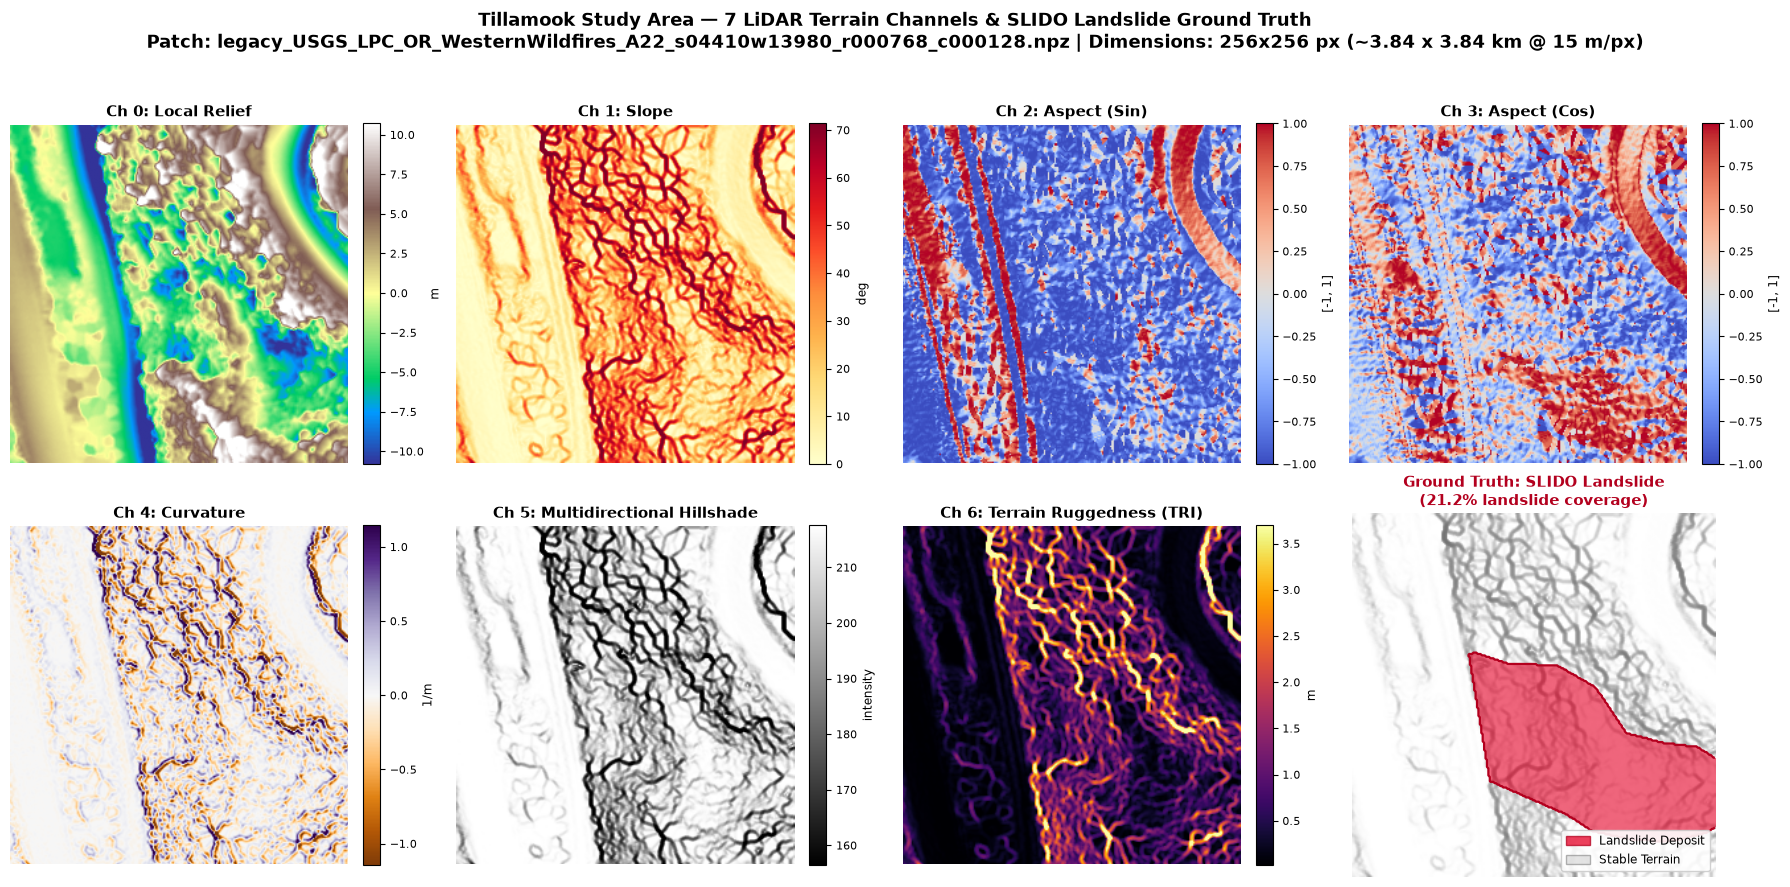

In [4]:
# ==============================================================================
# TILLAMOOK LIDAR CHANNELS VISUALIZATION
# Single self-contained code to load, analyze, and display all 7 LiDAR channels
# alongside the SLIDO Landslide Ground Truth Mask.
# ==============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ------------------------------------------------------------------------------
# 1. Dataset & Patch Discovery
# ------------------------------------------------------------------------------
# Candidate dataset directories in priority order
CANDIDATE_DIRS = [
    Path("dataset_tillamook_100_binary_15m_split641620"),
    Path("dataset_tillamook_probe_15m"),
    Path("dataset_tillamook_expansion_100_train_binary_15m")
]

dataset_dir = next((d for d in CANDIDATE_DIRS if d.exists()), None)
if dataset_dir is None:
    raise FileNotFoundError("No Tillamook LiDAR dataset directory found in current working directory.")

# Selection mode:
# - 'auto': Automatically finds a prominent landslide patch (30% - 55% coverage)
# - int: Zero-based index into patches.csv (e.g. 0, 10, 42)
# - str/Path: Exact file path to any .npz patch file
PATCH_SELECT = 'auto'

selected_patch_path = None
csv_path = dataset_dir / "patches.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
    if PATCH_SELECT == 'auto':
        # Select patch with clear, unambiguous landslide coverage
        subset = df[(df["positive_fraction"] >= 0.10) & 
                    (df["positive_fraction"] <= 0.25) & 
                    (df.get("ignore_fraction", 0) == 0)]
        if subset.empty:
            subset = df[df["positive_fraction"] > 0.05]
        if not subset.empty:
            selected_patch_path = dataset_dir / subset.iloc[0]["patch_path"]
    elif isinstance(PATCH_SELECT, int):
        selected_patch_path = dataset_dir / df.iloc[PATCH_SELECT]["patch_path"]
    elif isinstance(PATCH_SELECT, (str, Path)):
        selected_patch_path = Path(PATCH_SELECT)

# Fallback scan for .npz files if CSV is missing or path not found
if selected_patch_path is None or not selected_patch_path.exists():
    npz_files = list(dataset_dir.glob("**/*.npz"))
    if not npz_files:
        raise FileNotFoundError(f"No .npz patch files found in {dataset_dir}!")
    for p in npz_files:
        with np.load(p) as d:
            if (d["mask"] == 1).mean() > 0.10:
                selected_patch_path = p
                break
    if selected_patch_path is None:
        selected_patch_path = npz_files[0]

# ------------------------------------------------------------------------------
# 2. Load LiDAR Features & Ground Truth Mask
# ------------------------------------------------------------------------------
with np.load(selected_patch_path) as data:
    features = data["features"].astype(np.float32)  # Shape: (7, H, W)
    mask = data["mask"]                              # Shape: (H, W)

n_channels, H, W = features.shape
pos_pixels = int(np.sum(mask == 1))
total_pixels = mask.size
pos_pct = (pos_pixels / total_pixels) * 100.0
ignore_pixels = int(np.sum(mask == 255))
extent_km = (W * 15.0) / 1000.0  # 15m resolution -> 3.84 km

# Channel definitions: name, colormap, units, and geomorphological description
channels = [
    {"name": "Local Relief",              "cmap": "terrain",  "unit": "m",          "desc": "Detrended elevation highlighting ridges & valley bottoms"},
    {"name": "Slope",                     "cmap": "YlOrRd",   "unit": "deg",        "desc": "Surface steepness (critical gradient trigger for failure)"},
    {"name": "Aspect (Sin)",              "cmap": "coolwarm", "unit": "[-1, 1]",     "desc": "East-West orientation component (solar/wind exposure)"},
    {"name": "Aspect (Cos)",              "cmap": "coolwarm", "unit": "[-1, 1]",     "desc": "North-South orientation component (moisture regime)"},
    {"name": "Curvature",                 "cmap": "PuOr",     "unit": "1/m",        "desc": "Surface concavity/convexity (water flow convergence)"},
    {"name": "Multidirectional Hillshade","cmap": "gray",     "unit": "intensity",  "desc": "Omnidirectional shaded relief revealing scarps & deposits"},
    {"name": "Terrain Ruggedness (TRI)",  "cmap": "inferno",  "unit": "m",          "desc": "Elevation heterogeneity & hummocky deposit texture"}
]

# ------------------------------------------------------------------------------
# 3. Print Channel Statistics & Metadata
# ------------------------------------------------------------------------------
print("=" * 105)
print(f"TILLAMOOK LIDAR CHANNELS AUDIT: {selected_patch_path.name}")
print("=" * 105)
print(f"Dataset Directory : {dataset_dir.name}")
print(f"Patch Dimensions  : {n_channels} channels x {H} x {W} pixels")
print(f"Spatial Extent    : {extent_km:.2f} km x {extent_km:.2f} km (at 15 meters/pixel)")
print(f"Landslide Target  : {pos_pixels:,} / {total_pixels:,} pixels ({pos_pct:.2f}%) | Ignore pixels: {ignore_pixels:,}")
print("-" * 105)
print(f"{'Ch':<4} {'Channel Name':<28} {'Min':>9} {'Max':>9} {'Mean':>9} {'Std':>9} {'Unit':<10} {'Geomorphic Role'}")
print("-" * 105)

for i, ch in enumerate(channels):
    data_ch = features[i]
    c_min, c_max = float(np.nanmin(data_ch)), float(np.nanmax(data_ch))
    c_mean, c_std = float(np.nanmean(data_ch)), float(np.nanstd(data_ch))
    print(f"[{i}]  {ch['name']:<28} {c_min:>9.2f} {c_max:>9.2f} {c_mean:>9.2f} {c_std:>9.2f} {ch['unit']:<10} {ch['desc']}")
print("=" * 105)

# ------------------------------------------------------------------------------
# 4. Multi-Panel Visualization (2x4 Grid)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 9), facecolor="white")
axes = axes.flatten()

# Plot each of the 7 LiDAR channels
for i, ch in enumerate(channels):
    ax = axes[i]
    arr = features[i]
    
    # Robust percentile stretch (2% to 98%) to eliminate extreme outlier artifacts
    if ch["name"] == "Curvature":
        vmax = float(np.nanpercentile(np.abs(arr), 98))
        vmin = -vmax
    elif "Aspect" in ch["name"]:
        vmin, vmax = -1.0, 1.0
    else:
        vmin, vmax = np.nanpercentile(arr, [2, 98])
    
    im = ax.imshow(arr, cmap=ch["cmap"], vmin=vmin, vmax=vmax, interpolation="bilinear")
    ax.set_title(f"Ch {i}: {ch['name']}", fontsize=11, fontweight="bold", pad=6)
    ax.axis("off")
    
    # Colorbar with physical units
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=8)
    if ch["unit"]:
        cb.ax.set_ylabel(ch["unit"], rotation=90, fontsize=8.5)

# Panel 8: SLIDO Landslide Ground Truth Mask with Hillshade Context
ax = axes[7]
hillshade = features[5]
hill_norm = (hillshade - np.nanmin(hillshade)) / (np.nanmax(hillshade) - np.nanmin(hillshade) + 1e-6)

# Background hillshade in soft grayscale
ax.imshow(hill_norm, cmap="gray", alpha=0.55, interpolation="bilinear")

# Landslide deposit overlay in vivid red
masked_landslide = np.ma.masked_where(mask != 1, mask)
ax.imshow(masked_landslide, cmap=mcolors.ListedColormap(["#e60026"]), alpha=0.6, interpolation="nearest")

# Crisp boundary contour
if pos_pixels > 0:
    ax.contour(mask == 1, levels=[0.5], colors=["#b3001e"], linewidths=1.6)

# Ignore / boundary overlay (if present)
if ignore_pixels > 0:
    masked_ignore = np.ma.masked_where(mask != 255, mask)
    ax.imshow(masked_ignore, cmap=mcolors.ListedColormap(["#f5a623"]), alpha=0.5, interpolation="nearest")

ax.set_title(f"Ground Truth: SLIDO Landslide\n({pos_pct:.1f}% landslide coverage)", 
             fontsize=11, fontweight="bold", color="#b3001e", pad=6)
ax.axis("off")

# Legend for ground truth panel
legend_elements = [
    Patch(facecolor="#e60026", edgecolor="#b3001e", alpha=0.75, label="Landslide Deposit"),
    Patch(facecolor="lightgray", edgecolor="gray", alpha=0.6, label="Stable Terrain")
]
if ignore_pixels > 0:
    legend_elements.append(Patch(facecolor="#f5a623", edgecolor="#d48806", alpha=0.7, label="Ignore / Boundary"))

ax.legend(handles=legend_elements, loc="lower right", fontsize=8.5, framealpha=0.9, edgecolor="#cccccc")

fig.suptitle(f"Tillamook Study Area — 7 LiDAR Terrain Channels & SLIDO Landslide Ground Truth\n"
             f"Patch: {selected_patch_path.name} | Dimensions: 256x256 px (~{extent_km:.2f} x {extent_km:.2f} km @ 15 m/px)",
             fontsize=13, fontweight="bold", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save high-res PNG for easy reference
out_img = Path("tillamook_channels_plot.png")
fig.savefig(out_img, dpi=200, bbox_inches="tight")
print(f"\nSaved figure to: {out_img.resolve()}")

plt.show()
